В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [190]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, RocCurveDisplay, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings("ignore")

In [191]:
raw_df = pd.read_csv('train.csv')

# Перевіримо чи є пропущені дані:
display(raw_df.info())

# І загалом гляну, яку дані є в датасеті:
display(raw_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


None

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0
14998,14998,15732644.0,Fanucci,705.0,Spain,Female,40.0,7.0,0.00,2.0,1.0,0.0,149550.95,0.0


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [192]:
input_cols = list(raw_df.columns)[1:-1]
target_col = 'Exited'

X = raw_df[input_cols].copy()
y = raw_df[target_col].copy()

# Розбиваю на датасети: тренувальний і валідаційний
train_inputs, val_inputs, train_targets, val_targets = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

display(train_inputs.shape)
display(val_inputs.shape)

(13500, 12)

(1500, 12)

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [193]:
# Визначаю числові і категоріальні колонки:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# І одразу аналізую числові колонки:
train_inputs[numeric_cols].describe().round(2)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,13500.00,13500.00,13500.00,13500.00,13500.00,13500.00,13500.00,13500.00,13500.00
mean,15691187.46,658.75,37.72,5.02,42858.53,1.59,0.79,0.49,117901.24
std,140487.49,72.38,8.20,2.78,59778.57,0.53,0.41,0.50,45720.80
min,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,15635197.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83089.55
50%,15690164.00,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123663.63
75%,15756879.75,708.00,42.00,7.00,109655.05,2.00,1.00,1.00,156910.68
max,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


### Спостереження:

Половина клієнтів не тримає гроші на рахунку - баланс 0.00. Аналогічно перші два квартиля IsActiveMember == 0 (тобто половина клієнтів не є активними корстувачами). Всі клієнти користуються/користувались хоча б одним продуктом. Є клієнти, що не маюь в банку карток (користувались іншим продуктом).

### End of Спостереження


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [194]:
# 0. Перед початком:
display('Train dataset (before preprocessing): ', train_inputs[:5])
display('Validation dataset (before preprocessing): ', val_inputs[:5])

# 1. Імпутація даних не потрібна, адже всі колонки заповнені

# 2. Визначаю колонки, які будуть використані в моделі
# Id, CustomerId - поля, що не впливають на аналіх даних, тому їх можна видалити. Також `Surname` - категоріальна колонка, що має 748!!! унікальних значень. Її  не буду кодувати і видалю:
numeric_cols = [item for item in numeric_cols if item not in ['id', 'CustomerId']]
categorical_cols = [item for item in categorical_cols if item != 'Surname']

# 3. Використовую StandartScaler для масштабування числових даних:
scaler = StandardScaler()

scaler.fit(train_inputs[numeric_cols])

train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

# 4. Для категоріальних колонок Geography і Gender я використовую OneHotEncoder:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoder.fit(train_inputs[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)

train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

model_features = [*numeric_cols, *encoded_cols]

train_inputs_processed = train_inputs[model_features]
val_inputs_processed = val_inputs[model_features]

print()
print('--------------------------------')
print()
display('Train dataset (after preprocessing): ', train_inputs_processed[:5])
display('Validation dataset (after preprocessing): ', val_inputs_processed[:5])

'Train dataset (before preprocessing): '

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
14943,15737542.0,K?,699.0,France,Male,34.0,2.0,133800.98,1.0,1.0,0.0,169669.33
2135,15775572.0,Chidiebere,705.0,France,Male,34.0,0.0,81589.04,1.0,1.0,1.0,140166.95
11829,15603319.0,Milani,758.0,France,Female,26.0,10.0,0.00,2.0,1.0,0.0,111241.37
8755,15644551.0,Okwuadigbo,634.0,Germany,Female,28.0,6.0,129893.56,1.0,1.0,0.0,188203.58
8643,15601787.0,Tuan,734.0,Spain,Male,30.0,8.0,0.00,2.0,1.0,0.0,130514.78


'Validation dataset (before preprocessing): '

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
5113,15631893.0,Smith,712.0,France,Female,33.0,6.0,0.00,2.0,1.0,1.0,53584.03
9917,15741032.0,Iweobiegbulam,718.0,France,Female,46.0,1.0,0.00,1.0,1.0,0.0,118913.53
9145,15683403.0,MacDevitt,637.0,France,Male,29.0,9.0,143330.56,1.0,0.0,1.0,146411.70
10676,15702631.0,Bellucci,575.0,France,Female,34.0,2.0,0.00,2.0,0.0,0.0,53584.03
1565,15769312.0,Hs?eh,732.0,Spain,Female,32.0,4.0,153572.63,1.0,1.0,1.0,160979.66



--------------------------------



'Train dataset (after preprocessing): '

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
14943,0.556075,-0.453946,-1.086837,1.521378,-1.110721,0.517651,-0.982377,1.132308,1.0,0.0,0.0,0.0,1.0
2135,0.638970,-0.453946,-1.806103,0.647924,-1.110721,0.517651,1.017939,0.487011,1.0,0.0,0.0,0.0,1.0
11829,1.371209,-1.430077,1.790226,-0.716981,0.767612,0.517651,-0.982377,-0.145669,1.0,0.0,0.0,1.0,0.0
8755,-0.341954,-1.186044,0.351694,1.456011,-1.110721,0.517651,-0.982377,1.537702,0.0,1.0,0.0,1.0,0.0
8643,1.039629,-0.942011,1.070960,-0.716981,0.767612,0.517651,-0.982377,0.275892,0.0,0.0,1.0,0.0,1.0


'Validation dataset (after preprocessing): '

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
5113,0.735681,-0.575962,0.351694,-0.716981,0.767612,0.517651,1.017939,-1.406791,1.0,0.0,0.0,1.0,0.0
9917,0.818576,1.010250,-1.446470,-0.716981,-1.110721,0.517651,-0.982377,0.022141,1.0,0.0,0.0,1.0,0.0
9145,-0.300507,-1.064028,1.430593,1.680799,-1.110721,-1.931803,1.017939,0.623601,1.0,0.0,0.0,0.0,1.0
10676,-1.157089,-0.453946,-1.086837,-0.716981,0.767612,-1.931803,-0.982377,-1.406791,1.0,0.0,0.0,1.0,0.0
1565,1.011998,-0.697979,-0.367571,1.852139,-1.110721,0.517651,1.017939,0.942241,0.0,0.0,1.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [195]:
train_inputs_processed.to_parquet('train_inputs.parquet')
train_targets.to_frame().to_parquet('train_targets.parquet')
val_inputs_processed.to_parquet('val_inputs.parquet')
val_targets.to_frame().to_parquet('val_targets.parquet')

!ls .

log_reg.joblib		test.csv	       val_inputs.parquet
sample_data		train.csv	       val_targets.parquet
sample_submission.csv	train_inputs.parquet
submission_log_reg.csv	train_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [196]:
X_train = train_inputs_processed.copy()
X_val = val_inputs_processed.copy()

# Створюю і треную модель:
model = LogisticRegression(solver='liblinear')
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [197]:
def predict_and_plot(inputs, targets, name=''):
  # 1. Predict probabilities for the positive class
  probs = model.predict_proba(inputs)[:, 1]

  # 2. Predict the class labels
  preds = model.predict(inputs)

  # 3. Calculate and display the Confusion Matrix
  conf_matrix = confusion_matrix(targets, preds, normalize='true')
  print("Confusion Matrix ({name}):\n", conf_matrix)

  # 4. Calculate and display the F1 Score
  f1 = f1_score(targets, preds)
  print("F1 score: {:.2f}%".format(f1 * 100))

  # 5. Calculate and display the AUROC score
  roc_auc = roc_auc_score(targets, probs)
  print(f"AUROC Score ({name}): {roc_auc:.4f}")

  #6. Confusion Matrix plot:
  plt.figure()
  sns.heatmap(conf_matrix, annot=True)
  plt.xlabel('Prediction')
  plt.ylabel('Target')
  plt.title('{} Confusion Matrix'.format(name));

  return probs, preds

Confusion Matrix ({name}):
 [[0.95833721 0.04166279]
 [0.44776119 0.55223881]]
F1 score: 64.39%
AUROC Score (Training Data): 0.8841


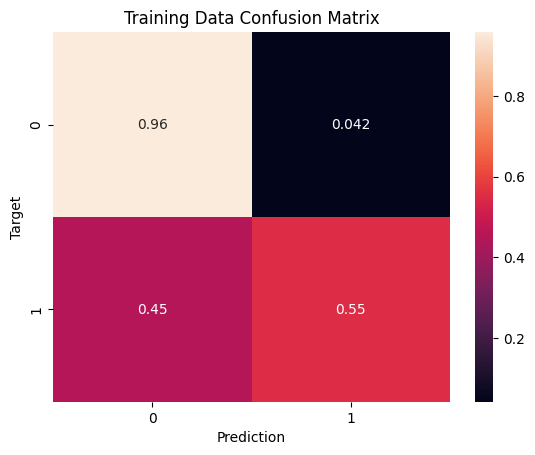

In [198]:
(train_probs, train_preds) = predict_and_plot(X_train, train_targets, 'Training Data')


Confusion Matrix ({name}):
 [[0.93807531 0.06192469]
 [0.46885246 0.53114754]]
F1 score: 59.89%
AUROC Score (Validation Data): 0.8594


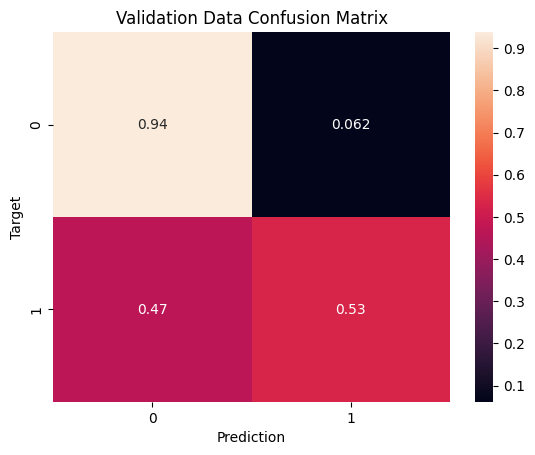

In [199]:
(val_probs, val_preds) = predict_and_plot(X_val, val_targets, 'Validation Data')

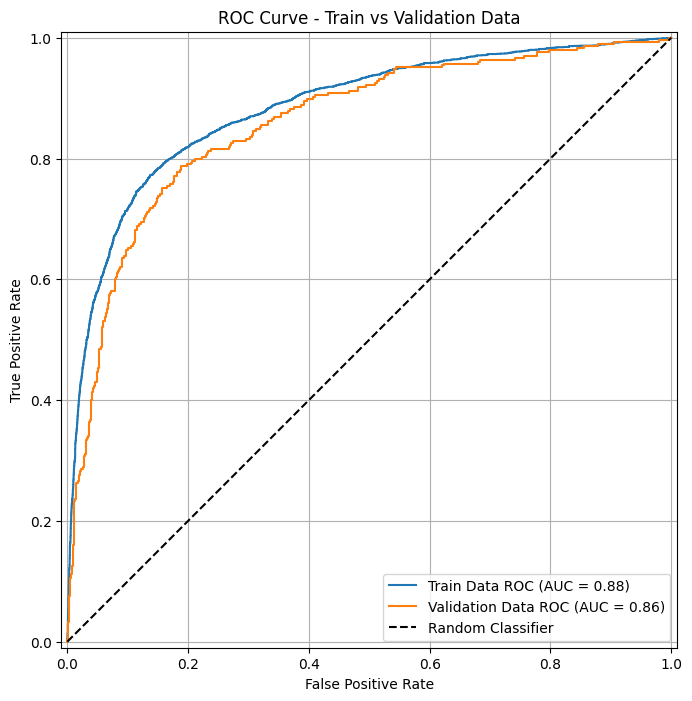

In [200]:
plt.figure(figsize=(10, 8))
ax = plt.gca()

RocCurveDisplay.from_estimator(model, X_train, train_targets, ax=ax, name='Train Data ROC')
RocCurveDisplay.from_estimator(model, X_val, val_targets, ax=ax, name='Validation Data ROC')

plt.title('ROC Curve - Train vs Validation Data')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.grid(True)
plt.show()


### Спостереження щодо якості моделі

**Метрики можелі на тренувальних даних:**
- **F1 Score:** 0.6439
- **AUROC Score:** 0.8841

**Метрики моделі на валідаційних даних:**
- **F1 Score:** 0.5989
- **AUROC Score:** 0.8594

На мій погляд логістична регресія в даному випадку демонструє **задовільну** якість.

*   **AUROC:** Обидві тренувальні (0.8841) і валідаційні (0.8594) AUROC показники хороші
*   **F1 Scores:** F1 метрики становлять 0.6439 для тренувальної і 0.5989 for для валідаційної. Вони не є скоріше посередні, ніж високі (можливо через незбалансованість моделі, тому що даних для значення 'Exited' 1 менше).

### End of Спостереження

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [201]:
majority_class = train_targets.value_counts().idxmax()
print(f"The majority class in train_targets is: {majority_class}")

The majority class in train_targets is: 0.0


In [202]:
# Передбачення для мажоритарного класу - тобто модель завжди повертає 0:
train_majority_preds = [majority_class] * len(train_targets)
val_majority_preds = [majority_class] * len(val_targets)

# Рахуємо точність на тренувальних і валідаційних даних:
majority_train_accuracy = accuracy_score(train_targets, train_majority_preds)
majority_val_accuracy = accuracy_score(val_targets, val_majority_preds)

print(f"Majority Class Accuracy (Training Data): {majority_train_accuracy:.4f}")
print(f"Majority Class Accuracy (Validation Data): {majority_val_accuracy:.4f}")

# Рахуємо точність для логістичної моделі
log_reg_train_accuracy = accuracy_score(train_targets, train_preds)
log_reg_val_accuracy = accuracy_score(val_targets, val_preds)

print(f"\nLogistic Regression Accuracy (Training Data): {log_reg_train_accuracy:.4f}")
print(f"Logistic Regression Accuracy (Validation Data): {log_reg_val_accuracy:.4f}")

Majority Class Accuracy (Training Data): 0.7965
Majority Class Accuracy (Validation Data): 0.7967

Logistic Regression Accuracy (Training Data): 0.8757
Logistic Regression Accuracy (Validation Data): 0.8553


### Спостереження

**Majority Class Baseline Accuracy:**
*   **Training Data:** 0.7965
*   **Validation Data:** 0.7967

**Logistic Regression Accuracy:**
*   **Training Data:** 0.8757
*   **Validation Data:** 0.8553

Модель мажоритарного класу посередня. На обох тренувальній і валідаційних моделях її точність 79.7%. Але це лише означчає, що вона точно передбачає, коли набільш поширене значення. І ніколи не передбачить в незбалансованому датасеті міноритарний клас.

Те, що логістична модель набагато точніше передбачає значення, говорить про те, що вона насправді натренована, а не просто вгадує значення.Тобто тренування було ефективним (також на цей висновок впливає те. що на валідаційних даних модель не сильно втрачає точність).

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [203]:
# Save the trained model & load it back
churn_model_data = {'model': model, 'scaler': scaler, 'encoder': encoder,
               'input_cols': input_cols, 'target_col': target_col, 'numeric_cols': numeric_cols,
               'categorical_cols': categorical_cols, 'encoded_cols': encoded_cols}
joblib.dump(churn_model_data, 'log_reg.joblib')
churn_model_data2 = joblib.load('log_reg.joblib')

model_2  = churn_model_data2['model']
display(model_2)

LogisticRegression(solver='liblinear')

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [204]:
def predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, encoded_cols, input_df: pd.DataFrame):
  input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])

  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
  training_cols = [*numeric_cols, *encoded_cols]
  X_input = input_df[training_cols]

  prob = model.predict_proba(X_input)[:,1]
  preds = model.predict(X_input)
  return prob, preds

In [205]:
predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, encoded_cols, raw_df[:5])

(array([0.00551349, 0.03167573, 0.37148501, 0.38745996, 0.98002571]),
 array([0., 0., 0., 0., 1.]))

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [206]:
test_raw_df = pd.read_csv('test.csv')
display(test_raw_df)

(test_prob, test_pred) = predict_raw_df(scaler, encoder, numeric_cols, categorical_cols, encoded_cols, test_raw_df)

test_raw_df['Exited'] = test_prob


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24995,15642997.0,Chukwumaobim,639.0,Spain,Male,38.0,10.0,0.00,2.0,1.0,1.0,49637.65
9996,24996,15739271.0,Clements,678.0,Spain,Male,39.0,9.0,0.00,2.0,1.0,1.0,142513.50
9997,24997,15756743.0,Chidiebere,774.0,France,Male,30.0,9.0,0.00,2.0,1.0,0.0,4861.72
9998,24998,15680167.0,Yermakova,595.0,France,Male,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [207]:
submission_df = pd.read_csv('sample_submission.csv')
display('Read from a file: ', submission_df[:5])
print()
print('------------------')
print()

submission_df['Exited'] = test_raw_df['Exited']
display('Predictied with log model: ', submission_df[:5])

submission_df.to_csv('submission_log_reg.csv', index=False)

'Read from a file: '

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5



------------------



'Predictied with log model: '

,id,Exited
0,15000,0.070748
1,15001,0.031110
2,15002,0.150771
3,15003,0.196376
4,15004,0.052014
